In [ ]:
!python -m pip install -r requirements.txt
import cv2
import numpy as np
import matplotlib.pyplot as plt

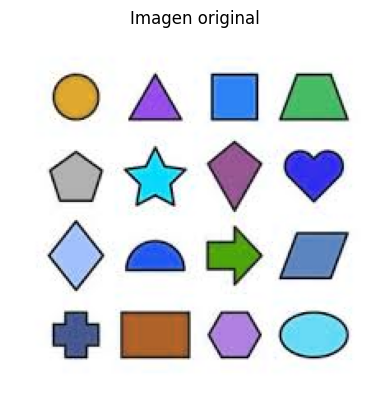

In [ ]:
img_path = "../media/image.png"
image = cv2.imread(img_path)

plt.imshow(image)
plt.title("Imagen original")
plt.axis("off")
plt.show()

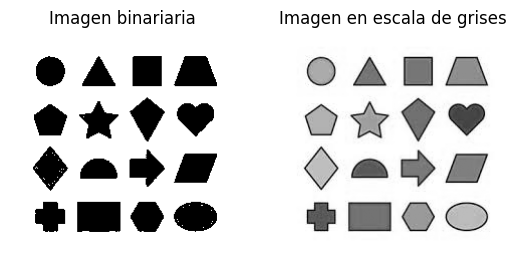

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
ret, threshold = cv2.threshold(gray, 210, 255, cv2.THRESH_BINARY)

titles = ["Imagen binariaria", "Imagen en escala de grises"]
ims = [threshold, gray]
for i, (t, im) in enumerate(zip(titles, ims)):
    plt.subplot(1, 2, i + 1)
    plt.imshow(im, "gray")
    plt.title(t)
    plt.axis("off")
plt.show()

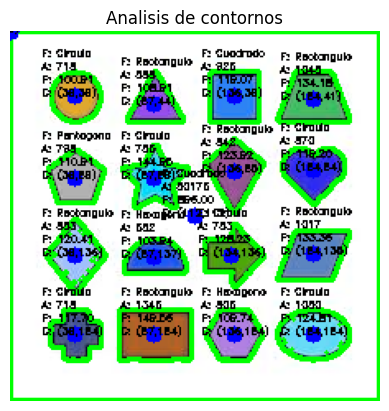

In [85]:
contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
output = image.copy()

def clasificar_contorno(cnt, perimetro):
    epsilon = 0.02 * perimetro
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    
    # Número de vértices encontrados
    vertices = len(approx)
    
    nombre_figura = "Desconocido"

    if vertices == 3:
        nombre_figura = "Triangulo"
        
    elif vertices == 4:
        # Para diferenciar entre cuadrado y rectángulo usamos la relación de aspecto
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        if 0.95 <= aspect_ratio <= 1.05:
            nombre_figura = "Cuadrado"
        else:
            nombre_figura = "Rectangulo"
            
    elif vertices == 5:
        nombre_figura = "Pentagono"
        
    elif vertices == 6:
        nombre_figura = "Hexagono"
        
    else:
        # Si tiene muchos vértices, asumimos que es un círculo
        nombre_figura = "Circulo"
    return nombre_figura

cv2.drawContours(output, contours, -1, (0, 255, 0), 2)
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0
    
    cv2.circle(output, (cx, cy), 5, (0, 0, 255), -1)
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    escala = 0.2
    color_texto = (0, 0, 0)
    
    cv2.putText(output, f"F: {clasificar_contorno(cnt, perimetro)}", (cx - 20, cy - 24), font, escala, color_texto, 1)
    cv2.putText(output, f"A: {int(area)}", (cx - 20, cy - 16), font, escala, color_texto, 1)
    cv2.putText(output, f"P: {perimetro:.2f}", (cx - 20, cy - 8), font, escala, color_texto, 1)
    cv2.putText(output, f"C: ({cx},{cy})", (cx - 20, cy), font, escala, color_texto, 1)

plt.imshow(output)
plt.title("Analisis de contornos")
plt.axis("off")
plt.show()